# Checking out BatchedLogistic works as expected

As we had done before in checking torch logistic we know are going to check if the batched logistic regression works as expected
with credit data as well

In [1]:
## Setting "base directory" for allowing imports
import os
import sys
import warnings

base_path = os.path.abspath("./..")
if base_path not in sys.path:
    sys.path.append(base_path)


# ============================
# Third-party imports
# ============================
from IPython.display import display, Markdown
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
import pandas as pd
import torch

from berebasl.evaluation.k_fold_validation import k_fold_cv_normalized_split
from berebasl.simulation.acceptance_loop import default_dgp
from berebasl.simulation.credit_data_simulation import CreditData, CreditDataGenerator
from dev.compare_torchlogit import fit_batched_logistic, fit_glm, fit_torch

# ============================
# Global configuration
# ============================
torch.set_default_dtype(torch.float64)
torch.set_printoptions(precision=6)
torch.set_num_threads(16)
torch.set_num_interop_threads(8)

In [ ]:
device = torch.device(
        "cuda" if torch.cuda.is_available() else 
        "mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available() else 
        "cpu"
    )
initial_seed = 1807
data_gen: CreditDataGenerator = default_dgp(
    seed_credit_data_gen=-initial_seed, 
    deterministic_weights_for_mixture_sampling=True,
    device=device,
    dtype=torch.get_default_dtype()
)

num_gens = 200
trials_per_gen = 200
init_sample_size = 400
sample_size = 160
k_folds = 4

data_gen.manual_seed(initial_seed)
features, labels = data_gen.sample(init_sample_size)

credit_data = CreditData(
    features, labels, 
    accepted_initial=torch.ones(labels.shape, dtype=torch.bool) # All are "accepted"
)
stats = []

In [3]:
from typing import Callable

def train_and_eval_folds(
        train_feats, 
        train_lbls, 
        train_masks, 
        feats_cv,
        mask_cv,
        k_folds: int,
        fit_unbatched: Callable,
        extract_params: Callable[["model"], torch.Tensor],
        model_name: str
    ):
    k_params, k_probs, k_train_times, k_inf_times = [],[],[],[]
    device = train_feats.device
    N = feats_cv.size(1)
    for k in range(k_folds):
        fold_feats, fold_lbls = [ten[k][train_masks[k]] for ten in (train_feats, train_lbls)]
        fitted_model, probs, train_time, inf_time = fit_unbatched(
                    fold_feats, 
                    fold_lbls,
                    X_vali = feats_cv[k]
                )
        
        k_params.append(extract_params(fitted_model).to(device))

        normalized_shape_probs = feats_cv.new_full((N, 2), fill_value=float('nan'))
        normalized_shape_probs[mask_cv[k]] = torch.from_numpy(probs).to(device) if isinstance(probs, np.ndarray) else probs
        k_probs.append(normalized_shape_probs)

        k_train_times.append(train_time)
        k_inf_times.append(inf_time)

    k_params, k_probs = [torch.stack(tens, dim=0) for tens in (k_params, k_probs)]
    train_stats_df = pd.DataFrame(
        {
            "train_time_" + model_name : k_train_times,
            "inf_time_" + model_name : k_inf_times
        },
        index=pd.Index(range(k_folds), name="k")
    )

    return k_params, k_probs, train_stats_df

l2_norm = lambda ten : torch.linalg.norm(ten, ord=2, dim=-1)
rel_l2_error = lambda new_beta, base_beta: l2_norm(new_beta - base_beta) / l2_norm(base_beta)
def compare_models_fit_to_glm(
        params_glm, glm_probs, 
        batched_lr, batched_probs,
        params_torch, torch_probs
):
    # Parameter comparision
    ml_calc_params = torch.stack([
        batched_lr.beta.squeeze(-1),
        params_torch
    ], dim=0)

    stats = pd.DataFrame(
        rel_l2_error(ml_calc_params, params_glm.unsqueeze(0)).T.detach().numpy(),
        index=pd.RangeIndex(params_glm.size(0), name="k"), columns=["params_rel_l2_err_batched", "params_rel_l2_err_torch"]
    )
    

    joint_probs_ml_last_class = torch.stack([batched_probs[...,-1], torch_probs[..., -1]],dim=0) # [2, k, row_folds]
    glm_probs_last_class = glm_probs[None, ..., -1]

    nans_glm = glm_probs_last_class.isnan()
    if not torch.all(nans_glm == joint_probs_ml_last_class.isnan()):
        raise AssertionError("Nans for different observations, panicking!!!")

    probs_diffs_last_class = glm_probs_last_class - joint_probs_ml_last_class
    abs_probs_diffs = probs_diffs_last_class.abs()

    stats["probs_mae_batched"], stats["probs_mae_torch"] = abs_probs_diffs.nanmean(dim=-1).detach().numpy()

    idx_worst = abs_probs_diffs.nan_to_num(nan=-float('inf')).argmax(axis=-1, keepdim=True)
    
    stats["probs_worst_err_batched"], stats["probs_worst_err_torch"] = probs_diffs_last_class.gather(
        dim=-1, index=idx_worst
    ).squeeze(-1).detach().numpy()

    
    same_preds_as_glm = (
        (glm_probs_last_class > 0.5) == (joint_probs_ml_last_class > 0.5)
    ).to(
        glm_probs_last_class.dtype
    ).masked_fill_(nans_glm, float('nan'))
        
    
    stats["pred_proportion_eq_batched"], stats["pred_proportion_eq_torch"] = same_preds_as_glm.nanmean(dim=-1).detach().numpy()
    
    
    return stats


In [4]:
for gen_nr in range(1, num_gens + 1):
    if gen_nr % 5 == 0:
        print("\n")
        print("-- Iteration", f"{gen_nr}/{num_gens}:", credit_data.count_accepts, 
              "accepts and", credit_data.count_rejects, " rejects")
        print("\n")

    data_gen.manual_seed(initial_seed + gen_nr)
    features, labels = data_gen.sample(sample_size)

    credit_data.add_gen(
        features,
        labels,
        accepted_new=torch.ones(labels.shape, dtype=torch.bool)
    )

    features, labels = credit_data.unbiased_obs(include_gen_round=False)
    feats_cv, lbls_cv, mask_valid_cv = k_fold_cv_normalized_split(features, labels, rng=data_gen.rng, k=k_folds)

    arange_kfold = torch.arange(k_folds, device=device)
    train_idxs = torch.where(arange_kfold.unsqueeze(0) != arange_kfold.unsqueeze(1))[1].reshape(k_folds,k_folds-1)
    train_feats, train_lbls, train_masks = [ten[train_idxs].flatten(1,2) for ten in (feats_cv, lbls_cv, mask_valid_cv)]

    
    current_gen_stats = []
    for trial_nr in range(trials_per_gen):
        batched_lr, batched_probs, train_time_batched, inf_time_batched = fit_batched_logistic(train_feats, train_lbls, train_masks, X_vali=feats_cv)
        params_glm, glm_probs, times_glm = train_and_eval_folds(
            train_feats, train_lbls, train_masks, feats_cv, mask_valid_cv, k_folds,
            fit_unbatched= lambda X, lbl, X_vali : fit_glm(*[ten.detach().numpy() for ten in (X, lbl, X_vali)]),
            extract_params= lambda fitted_glm : torch.from_numpy(fitted_glm.params),
            model_name = "glm"
        )
        params_torch, torch_probs, times_torch = train_and_eval_folds(
            train_feats, train_lbls, train_masks, feats_cv, mask_valid_cv, k_folds,
            fit_unbatched= fit_torch,
            extract_params= lambda fitted_torch: torch.cat([fitted_torch.lin_estimator.bias.data, fitted_torch.lin_estimator.weight.data.squeeze(0)], dim=0),
            model_name = "torch"
        )

        trial_times_report = pd.concat((times_glm, times_torch), axis=1)
        trial_times_report["train_time_batched"] = train_time_batched / k_folds
        trial_times_report["inf_time_batched"] = inf_time_batched / k_folds

        trial_times_report.index = pd.MultiIndex.from_product(
            [[gen_nr], [trial_nr], trial_times_report.index], 
            names=("gen", "trial", trial_times_report.index.name)
        )
        comparision_stats = compare_models_fit_to_glm(
            params_glm, glm_probs, 
            batched_lr, batched_probs,
            params_torch, torch_probs
        )

        joint_stats = trial_times_report.join(comparision_stats, on='k')
        current_gen_stats.append(joint_stats)

    
    current_gen_stats = pd.concat(current_gen_stats)
    current_gen_stats["obs_count"] = len(credit_data)
    stats.append(current_gen_stats.copy())

stats = pd.concat(stats)



-- Iteration 5/20: 1040 accepts and 0  rejects




-- Iteration 10/20: 1840 accepts and 0  rejects




-- Iteration 15/20: 2640 accepts and 0  rejects




-- Iteration 20/20: 3440 accepts and 0  rejects




In [5]:
def group_stats(statistics_with_obs_count, obs_count_per_gen, keep_obs_count):
    def grouper(group):
        agg_group = group.drop(columns="obs_count")
        grouping = pd.concat([agg_group.agg(["mean"]), agg_group.quantile([0.05, 0.95])])
        obs_count = group["obs_count"].iloc[0]
        if keep_obs_count:
            grouping["obs_count"] = obs_count

        return grouping

    grouped_stats = (
        statistics_with_obs_count
        .join(obs_count_per_gen, on='gen')
        .groupby(level='gen')
        .apply(grouper)
        .unstack(level=1)
    )
    return grouped_stats

def add_single_level_on_top_to_cols_df(df, single_level, single_level_lbl = None):
    new_names = None if single_level_lbl is None else [single_level_lbl] + df.columns.names
    df.columns = pd.MultiIndex.from_arrays([
        [single_level] * df.shape[1],
        *[df.columns.get_level_values(li) for li in range(df.columns.nlevels)]
    ])
    return df

obs_count_per_gen = stats.loc[pd.IndexSlice[:, 0,0], ["obs_count"]].droplevel(level=["trial", "k"])
per_fold_based_stats = stats.drop(columns='obs_count').groupby(level=['gen', 'trial']).mean()
per_cv_based_time_stats = stats[trial_times_report.columns].groupby(level=['gen', 'trial']).sum()

grouped_fold_based_times = add_single_level_on_top_to_cols_df(
    group_stats(per_fold_based_stats[trial_times_report.columns], obs_count_per_gen, keep_obs_count=False),
    "Fold"
)
grouped_cv_based_times = add_single_level_on_top_to_cols_df(
    group_stats(per_cv_based_time_stats, obs_count_per_gen, keep_obs_count=False),
    "CV"
)
grouped_performance_stats = add_single_level_on_top_to_cols_df(
    group_stats(per_fold_based_stats.drop(columns=trial_times_report.columns), obs_count_per_gen, keep_obs_count=True),
    "Statistical Performance"
)

all_stats = pd.concat([grouped_fold_based_times, grouped_cv_based_times, grouped_performance_stats], axis=1)

In [6]:
def scatter_with_minmax(ax, x, y, lower_q, higher_q, label, c, s=3):
    ax.scatter(
        x,
        y,
        label=label,
        s = s,
        c = c
    )
    ax.plot(
        x,
        lower_q,
        c= to_rgba(c)[:3] + (0.2,)
    )
    ax.plot(
        x,
        lower_q,
        c=to_rgba(c)[:3] + (0.2,)
    )
    ax.plot(
        x,
        higher_q,
        c=to_rgba(c)[:3] + (0.2,)
    )
    return ax

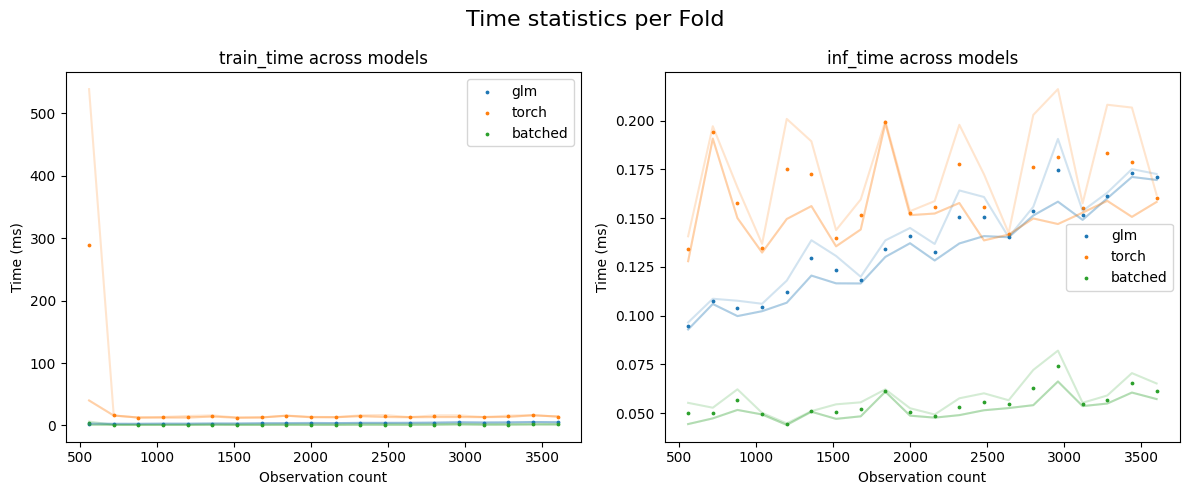

### Obs-Count unconditional descriptive time statistics per Fold

inf                            train                      
         batched        glm      torch    batched        glm      torch
count  20.000000  20.000000  20.000000  20.000000  20.000000  20.000000
mean    0.000055   0.000136   0.000164   0.001387   0.003855   0.028009
std     0.000007   0.000025   0.000019   0.000605   0.000893   0.061504
min     0.000044   0.000095   0.000134   0.000873   0.002611   0.012509
25%     0.000050   0.000117   0.000152   0.001060   0.003093   0.013275
50%     0.000054   0.000137   0.000159   0.001238   0.003829   0.014499
75%     0.000058   0.000152   0.000178   0.001459   0.004539   0.015257
max     0.000074   0.000175   0.000199   0.003655   0.005451   0.289263

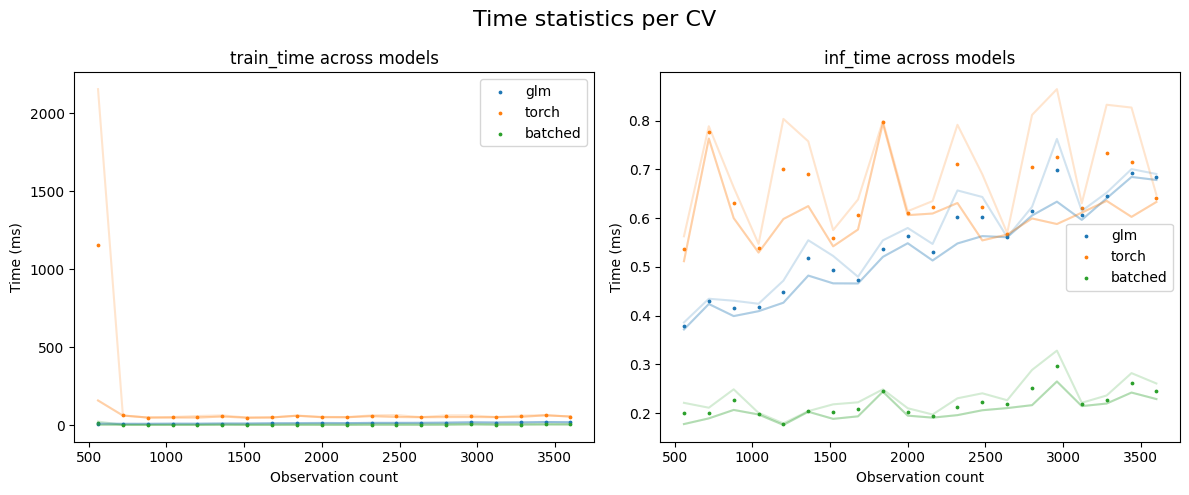

### Obs-Count unconditional descriptive time statistics per CV

inf                            train                      
         batched        glm      torch    batched        glm      torch
count  20.000000  20.000000  20.000000  20.000000  20.000000  20.000000
mean    0.000221   0.000546   0.000656   0.005546   0.015421   0.112036
std     0.000028   0.000098   0.000077   0.002418   0.003572   0.246015
min     0.000178   0.000379   0.000537   0.003491   0.010443   0.050035
25%     0.000202   0.000467   0.000610   0.004238   0.012372   0.053099
50%     0.000216   0.000549   0.000636   0.004950   0.015315   0.057995
75%     0.000232   0.000608   0.000712   0.005837   0.018157   0.061030
max     0.000297   0.000698   0.000797   0.014622   0.021804   1.157052

In [7]:
obs_counts = obs_count_per_gen["obs_count"]

models = ["glm", "torch", "batched"]

times_cats = ["Fold", "CV"]

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
colors_to_use = {m: c for m, c in zip(models, plt.rcParams["axes.prop_cycle"].by_key()["color"][:len(models)])}

for times_cat in times_cats:
    grouped_stats = all_stats[times_cat]
    fig, axes = plt.subplots(ncols=2, figsize=(12,5))


    for ax, error_type in zip(axes, ["train", "inf"]):
        for model in models:
            scatter_with_minmax(
                ax,
                x=obs_counts,
                y=grouped_stats[f"{error_type}_time_{model}"]["mean"] * 1e3,
                lower_q=grouped_stats[f"{error_type}_time_{model}"][0.05] * 1e3,
                higher_q=grouped_stats[f"{error_type}_time_{model}"][0.95] * 1e3,
                label=model,
                c=colors_to_use[model]
            )
        ax.legend()
        ax.set_title(f"{error_type}_time across models")
        ax.set_xlabel("Observation count")
        ax.set_ylabel("Time (ms)")

    fig.suptitle("Time statistics per "+ times_cat, fontsize=16)

    fig.tight_layout()

    plt.show()

    time_means = grouped_stats.swaplevel(0,1,axis="columns")["mean"]
    time_means.columns=pd.MultiIndex.from_tuples([(c[:c.find('_')], c[::-1][:c[::-1].find('_')][::-1]) for c in time_means.columns])
    time_means.sort_index(axis=1, inplace=True)
    display(Markdown("### Obs-Count unconditional descriptive time statistics per " + times_cat))
    display(time_means.describe().sort_index(axis=1))
    

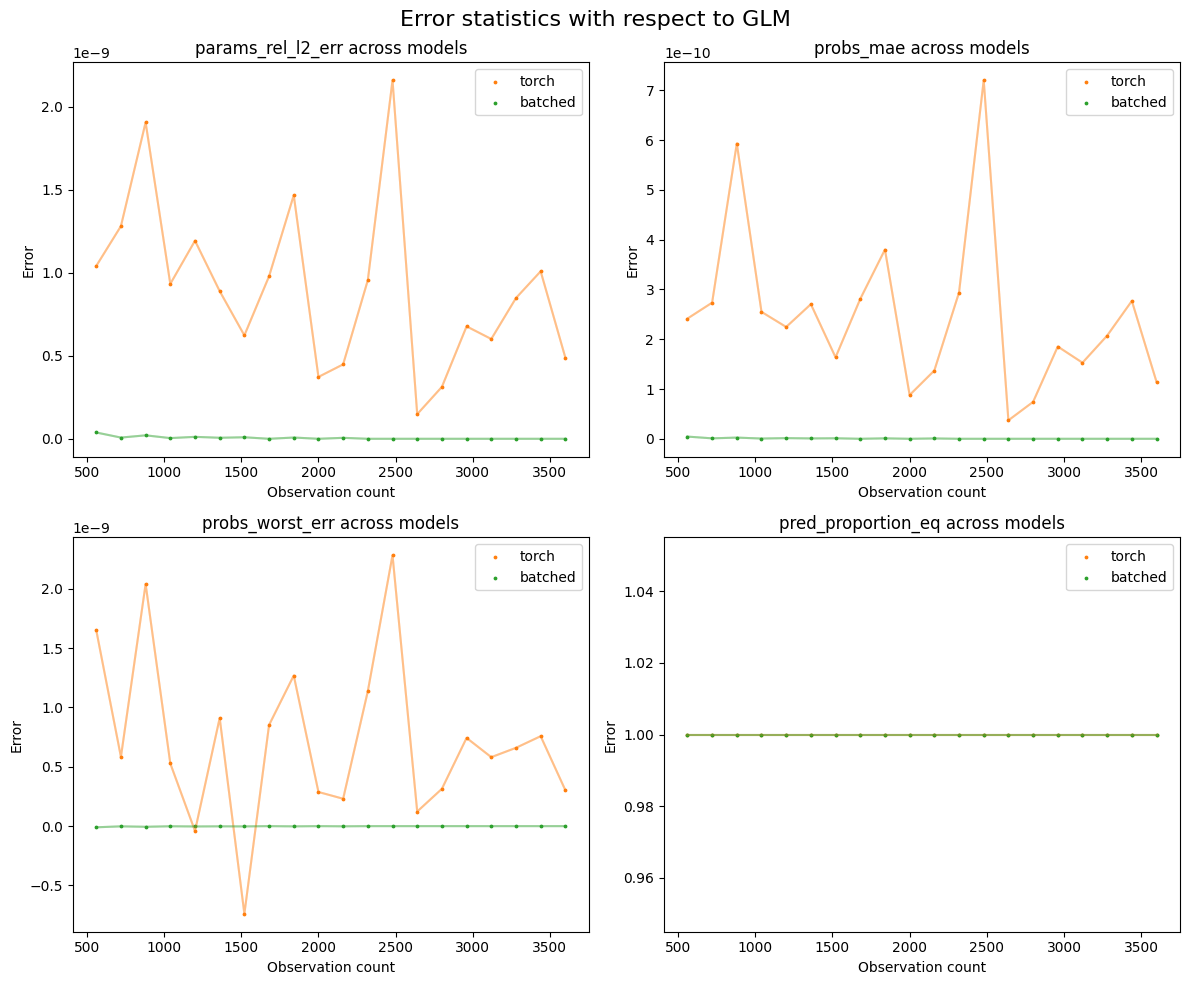

In [8]:
grouped_stats = all_stats["Statistical Performance"]
fig, axes = plt.subplots(nrows= 2, ncols=2, figsize=(12,10))

for ax, error_type in zip(axes.flatten(), ["params_rel_l2_err", "probs_mae", "probs_worst_err","pred_proportion_eq"]):
    for model in models[1:]:
        scatter_with_minmax(
            ax,
            x=obs_counts,
            y=grouped_stats[f"{error_type}_{model}"]["mean"],
            lower_q=grouped_stats[f"{error_type}_{model}"][0.05],
            higher_q=grouped_stats[f"{error_type}_{model}"][0.95],
            label=model,
            c=colors_to_use[model]
        )
    ax.legend()
    ax.set_title(f"{error_type} across models")
    ax.set_xlabel("Observation count")
    ax.set_ylabel("Error")

fig.suptitle("Error statistics with respect to GLM", fontsize=16)

fig.tight_layout()

plt.show()